# All-Tokenizers Sweep -- Full Result Analysis

**Sweep**: `outputs/experiments/all_tokenizers_sweep/`
**Reference baseline**: `outputs/experiments/native_llama_3phase_with_sft/` (Llama-3.2-1B's own tokenizer)
**Pipeline**: 3-phase (embedding-alignment -> warmup -> SFT) on Llama-3.2-1B
**Eval**: full benchmark on ACVA, Alghafa, Arabic-Exam (LightEval log-likelihood MCQ, char+PMI normalization)
**Tokenizers**: 8 from-scratch + native_llama reference

| # | Tokenizer | Family | Embedding | Notes |
|---|---|---|---|---|
| ref | **native_llama** | pretrained | standard | Llama-3.2-1B's own tokenizer; Phase 1 skipped |
| 1 | bpe_32k | subword | standard | ByteLevel BPE |
| 2 | wordpiece_32k | subword | standard | WordPiece |
| 3 | morpho_bpe_32k | subword | standard | Farasa pre-segmentation + BPE |
| 4 | character_bert | word+CharCNN | character_cnn | word-level, CharCNN embedding |
| 5 | farasa_character_bert | morpheme+CharCNN | character_cnn | Farasa pre-seg + CharCNN |
| 6 | char_jaber | character | char_jaber | one char per token |
| 7 | charformer | byte-level | charformer | GBST learned blocks (training crashed) |
| 8 | araroopat | root+pattern | standard | CAMeL Tools morphological decomposition |

**Sections:**

1. Tokenizer summary (with native_llama reference row)
2. Intrinsic metrics -- vocab / fertility / compression / UNK / coverage
3. Morphological metrics -- RPS / PIS / integrity / CSA / SFR / bearing-token %
4. Training dynamics -- per-phase wall-time, train-loss, SFT eval-loss curves
5. Downstream accuracy -- char-norm vs PMI, delta vs native_llama, per-sub-config heatmaps
6. MEI (Morphological Efficiency Index)
7. UNK analysis -- intrinsic + downstream (the key diagnostic)
8. Failure analysis -- confidence margin distributions
9. Intrinsic-to-downstream correlation analysis
10. Conclusions and recommendations

> **Charformer note**: training failed mid-pipeline (`Expected input batch_size (2024) to match target batch_size (2020).`). Only its intrinsic metrics are available.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import os
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:.4f}" if isinstance(x, float) else str(x))
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 40)

SWEEP_DIR = Path("/home/s3user/tokenizers_evaluation/outputs/experiments/all_tokenizers_sweep")
NATIVE_DIR = Path("/home/s3user/tokenizers_evaluation/outputs/experiments/native_llama_3phase_with_sft")

# Canonical ordering: native_llama first (reference), then the 8 from-scratch.
TOKENIZERS = [
    "native_llama",
    "bpe_32k",
    "wordpiece_32k",
    "morpho_bpe_32k",
    "character_bert",
    "farasa_character_bert",
    "char_jaber",
    "charformer",
    "araroopat",
]
TRAINED_TOKENIZERS = [t for t in TOKENIZERS if t != "charformer"]
TASKS = ["acva", "alghafa", "arabic_exam"]

PALETTE = {
    "native_llama":          "#000000",
    "bpe_32k":               "#1f77b4",
    "wordpiece_32k":         "#ff7f0e",
    "morpho_bpe_32k":        "#2ca02c",
    "character_bert":        "#d62728",
    "farasa_character_bert": "#9467bd",
    "char_jaber":            "#8c564b",
    "charformer":            "#e377c2",
    "araroopat":             "#17becf",
}

# Short display labels for compact plots.
SHORT = {
    "native_llama": "native",
    "bpe_32k": "BPE",
    "wordpiece_32k": "WP",
    "morpho_bpe_32k": "MorphBPE",
    "character_bert": "CharBERT",
    "farasa_character_bert": "FarasaCB",
    "char_jaber": "charJABER",
    "charformer": "Charformer",
    "araroopat": "AraRooPat",
}

# Mechanical-extreme flags.
RPS_MECHANICAL = {"character_bert", "farasa_character_bert", "araroopat"}
RPS_FLOOR      = {"char_jaber", "charformer"}

# Helper: detect script of a word for the UNK tables.
def detect_script(word: str) -> str:
    """Classify a word's script as Arabic, Latin, CJK, Symbol, or Mixed."""
    if not isinstance(word, str) or not word:
        return "empty"
    scripts = set()
    for ch in word:
        cp = ord(ch)
        if 0x0600 <= cp <= 0x06FF or 0x0750 <= cp <= 0x077F or 0xFB50 <= cp <= 0xFDFF or 0xFE70 <= cp <= 0xFEFF:
            scripts.add("Arabic")
        elif 0x0041 <= cp <= 0x007A or 0x00C0 <= cp <= 0x024F:
            scripts.add("Latin")
        elif 0x4E00 <= cp <= 0x9FFF or 0x3040 <= cp <= 0x30FF or 0x3400 <= cp <= 0x4DBF:
            scripts.add("CJK/Kana")
        elif ch in ' \t\n':
            pass  # whitespace
        elif unicodedata.category(ch).startswith(("P", "S")):
            scripts.add("Symbol")
        elif unicodedata.category(ch).startswith("N"):
            scripts.add("Digit")
        else:
            scripts.add("Other")
    if not scripts:
        return "empty"
    if len(scripts) == 1:
        return scripts.pop()
    return "Mixed(" + "+".join(sorted(scripts)) + ")"


# Helper: style reference row.
def highlight_ref(row):
    return ["background-color: #e6f3ff"] * len(row) if row.name == "native_llama" else [""] * len(row)

def color_delta(val):
    if pd.isna(val): return ""
    return "color: green; font-weight: bold" if val > 0.005 else ("color: red" if val < -0.005 else "color: grey")


print(f"Sweep directory : {SWEEP_DIR}")
print(f"Reference dir   : {NATIVE_DIR}")
print(f"Tokenizers ({len(TOKENIZERS)}): {', '.join(SHORT[t] for t in TOKENIZERS)}")

Sweep directory : /home/s3user/tokenizers_evaluation/outputs/experiments/all_tokenizers_sweep
Reference dir   : /home/s3user/tokenizers_evaluation/outputs/experiments/native_llama_3phase_with_sft
Tokenizers (9): native, BPE, WP, MorphBPE, CharBERT, FarasaCB, charJABER, Charformer, AraRooPat


In [2]:
# Load records. native_llama comes from a separate dir; sweep tokenizers from the sweep dir.
def load_record(tok: str) -> dict:
    d = NATIVE_DIR if tok == "native_llama" else SWEEP_DIR / tok
    rec = {"name": tok, "ok": False, "error": None}
    if (d / "all_metrics.json").exists():
        with open(d / "all_metrics.json") as fh:
            rec.update(json.load(fh))
        rec["ok"] = True
    elif (d / "intrinsic_metrics.json").exists():
        with open(d / "intrinsic_metrics.json") as fh:
            rec["intrinsic"] = json.load(fh)
        cr = SWEEP_DIR / "comparison_report.json"
        if cr.exists():
            rec["error"] = json.loads(cr.read_text()).get(tok, {}).get("error")
    return rec


RECORDS = {tok: load_record(tok) for tok in TOKENIZERS}

for tok, r in RECORDS.items():
    status = "OK" if r["ok"] else f"intrinsic-only ({r.get('error', '?')!r})"
    marker = ">>" if tok == "native_llama" else "  "
    print(f"  {marker} {tok:<25s} {status}")

  >> native_llama              OK
     bpe_32k                   OK
     wordpiece_32k             OK
     morpho_bpe_32k            OK
     character_bert            OK
     farasa_character_bert     OK
     char_jaber                OK
     charformer                intrinsic-only ('Expected input batch_size (2024) to match target batch_size (2020).')
     araroopat                 OK


## 2. Tokenizer summary

One row per tokenizer. **native_llama** (blue row) is the reference baseline.

- `delta_acc` = mean PMI accuracy minus native_llama's mean.
- Positive delta (green) = improvement over pretrained tokenizer.

In [3]:
def summary_row(tok: str) -> dict:
    r = RECORDS[tok]
    intr = r.get("intrinsic", {})
    row = {
        "tokenizer":       tok,
        "family":          {"native_llama": "pretrained", "bpe_32k": "subword", "wordpiece_32k": "subword",
                            "morpho_bpe_32k": "subword", "character_bert": "CharCNN", "farasa_character_bert": "CharCNN",
                            "char_jaber": "char", "charformer": "byte", "araroopat": "root+pat"}[tok],
        "vocab":           intr.get("vocab_size"),
        "fertility":       intr.get("fertility"),
        "compression":     intr.get("compression_ratio"),
        "unk_rate":        intr.get("unk_rate"),
        "vocab_coverage":  intr.get("vocab_coverage"),
        "RPS":             intr.get("root_conservation_rate"),
        "SFR":             intr.get("semantic_fragmentation_ratio"),
    }
    if r["ok"]:
        accs = [r["downstream"].get(t, {}).get("accuracy_pmi") for t in TASKS]
        accs_clean = [a for a in accs if a is not None]
        row["mean_acc_pmi"] = float(np.mean(accs_clean)) if accs_clean else None
        total_sec = sum(
            (r["training"].get(ph, {}) or {}).get("wall_time_sec") or 0.0
            for ph in ("embedding_alignment", "warmup", "sft")
        )
        row["train_min"] = total_sec / 60.0
    else:
        row["mean_acc_pmi"] = None
        row["train_min"]    = None
    return row


summary_df = pd.DataFrame([summary_row(t) for t in TOKENIZERS]).set_index("tokenizer")
ref_acc = summary_df.loc["native_llama", "mean_acc_pmi"]
summary_df["delta_acc"] = summary_df["mean_acc_pmi"] - ref_acc

display(summary_df.style
    .apply(highlight_ref, axis=1)
    .applymap(color_delta, subset=["delta_acc"])
    .format("{:.4f}", subset=[c for c in summary_df.columns if summary_df[c].dtype.kind == "f"], na_rep="--")
)

,family,vocab,fertility,compression,unk_rate,vocab_coverage,RPS,SFR,mean_acc_pmi,train_min,delta_acc
tokenizer,,,,,,,,,,,
native_llama,pretrained,128256,2.2795,2.5771,0.0000,1.0000,0.0198,1.8088,0.3835,13.7662,0.0000
bpe_32k,subword,32000,1.3685,4.2926,0.0000,1.0000,0.0705,1.1761,0.4052,20.2913,0.0217
wordpiece_32k,subword,32000,1.4033,4.1862,0.0000,0.9999,0.1872,1.0101,0.4110,8.2157,0.0275
morpho_bpe_32k,subword,32000,1.9222,3.0562,0.0000,0.9999,0.3128,1.1373,0.3682,7.1617,-0.0153
character_bert,CharCNN,50004,1.0058,5.8405,0.1374,0.1495,0.5969,0.3825,0.4104,7.8158,0.0269
farasa_character_bert,CharCNN,50004,1.8531,3.1700,0.0124,0.8093,0.4493,1.0000,0.4183,6.9542,0.0348
char_jaber,char,5603,5.8803,0.9990,0.0000,0.9999,0.0000,2.6234,0.4204,5.7575,0.0369
charformer,byte,260,10.5427,0.5572,0.0000,1.0000,0.0000,5.0842,--,--,--
araroopat,root+pat,3784,5.7445,1.0226,0.0105,0.9311,0.1696,3.6175,0.3931,5.4445,0.0096


## 3. Intrinsic metrics

### 3.1 Vocab, fertility, compression

- **fertility** = avg tokens per whitespace word. Lower = more compact encoding.
- **compression** = avg characters per token. Higher = each token carries more info.
- native_llama (128k vocab, multilingual BPE) sits at fertility 2.28 -- the cost of a non-Arabic-specialized tokenizer.

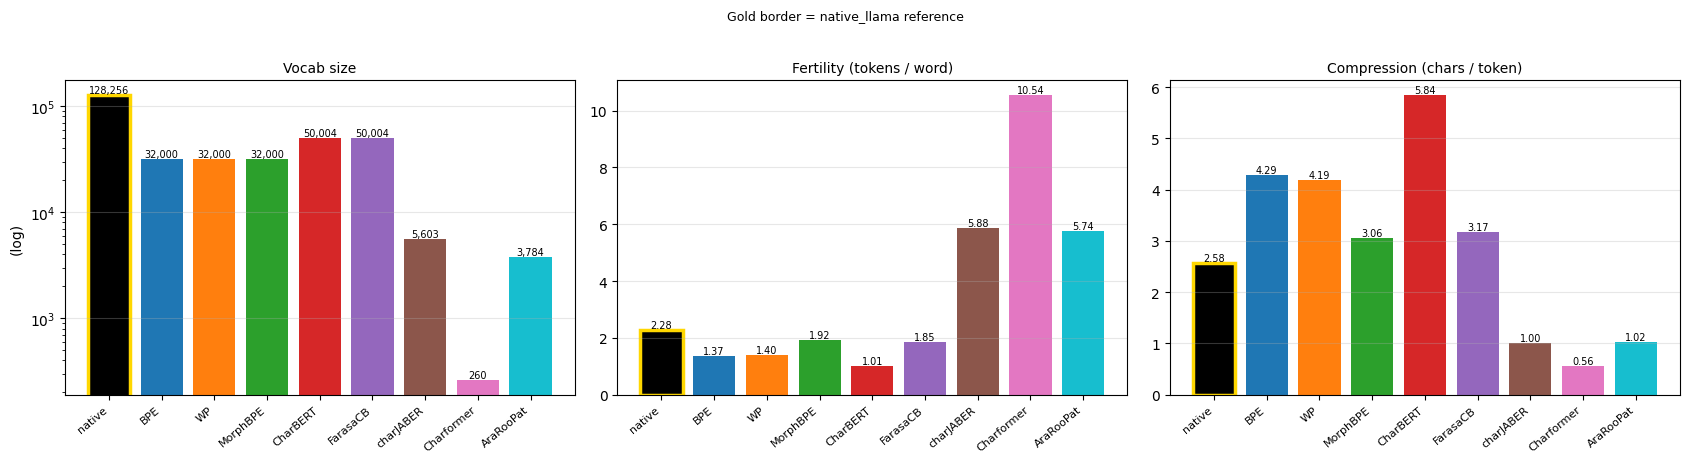

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

metrics_plot = [("vocab", "Vocab size", True),
                ("fertility", "Fertility (tokens / word)", False),
                ("compression", "Compression (chars / token)", False)]

for ax, (col, title, log_y) in zip(axes, metrics_plot):
    vals = summary_df[col].fillna(0)
    colors = [PALETTE[t] for t in vals.index]
    edge = ["gold" if t == "native_llama" else "none" for t in vals.index]
    lw   = [2.5 if t == "native_llama" else 0 for t in vals.index]
    bars = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor=edge, linewidth=lw)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([SHORT[t] for t in vals.index], rotation=40, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10); ax.grid(axis="y", alpha=0.3)
    if log_y:
        ax.set_yscale("log"); ax.set_ylabel("(log)")
    for b, v in zip(bars, vals.values):
        if v > 0:
            label = f"{int(v):,}" if col == "vocab" else f"{v:.2f}"
            ax.text(b.get_x() + b.get_width() / 2, v, label, ha="center", va="bottom", fontsize=7)

fig.suptitle("Gold border = native_llama reference", fontsize=9, y=1.02)
plt.tight_layout(); plt.show()

### 3.2 UNK rate and vocab coverage

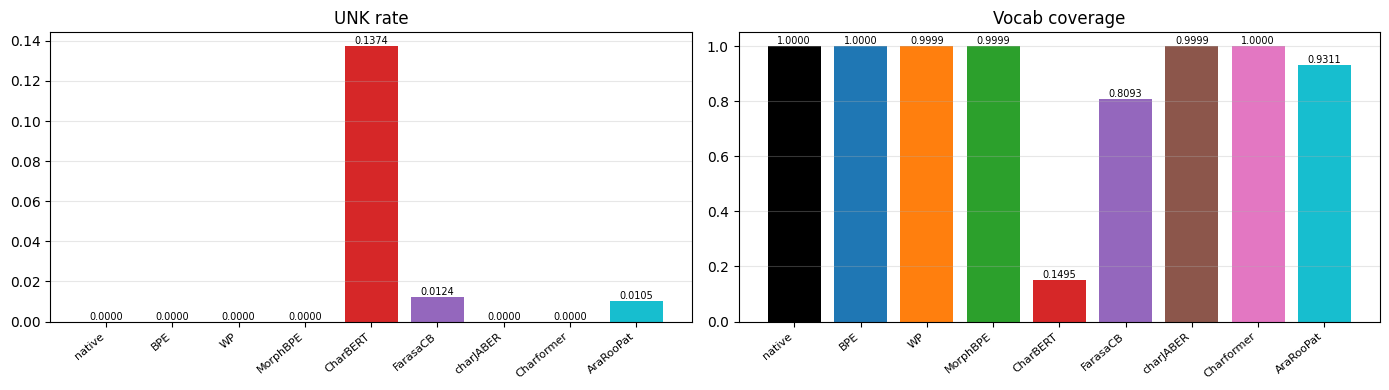

,vocab,unk_rate,vocab_coverage
tokenizer,,,
native_llama,128256.0000,0.0000,1.0000
bpe_32k,32000.0000,0.0000,1.0000
wordpiece_32k,32000.0000,0.0000,0.9999
morpho_bpe_32k,32000.0000,0.0000,0.9999
character_bert,50004.0000,0.1374,0.1495
farasa_character_bert,50004.0000,0.0124,0.8093
char_jaber,5603.0000,0.0000,0.9999
charformer,260.0000,0.0000,1.0000
araroopat,3784.0000,0.0105,0.9311


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (col, title) in zip(axes, [("unk_rate", "UNK rate"), ("vocab_coverage", "Vocab coverage")]):
    vals = summary_df[col].fillna(0)
    bars = ax.bar(range(len(vals)), vals.values, color=[PALETTE[t] for t in vals.index])
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([SHORT[t] for t in vals.index], rotation=40, ha="right", fontsize=8)
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout(); plt.show()

display(summary_df[["vocab", "unk_rate", "vocab_coverage"]].style
    .apply(highlight_ref, axis=1).format("{:.4f}", na_rep="--"))

**Key observations:**
- `character_bert`: `vocab_coverage = 0.15`, `unk_rate = 0.14` -- the 50k word-level output head misses 85% of eval words. This directly poisons downstream results.
- `farasa_character_bert`: morpheme inventory covers more -> coverage 0.81 (much better).
- `araroopat`: `unk_rate = 0.011` -- bounded by CAMeL database coverage (loanwords/proper nouns).
- Everyone else: essentially zero UNKs (complete subword/char/byte cover).

## 4. Morphological metrics

| Metric | Measures | Mechanical extremes |
|---|---|---|
| **RPS** (root conservation) | root letters inside one token | CharBERT/AraRooPat: ceiling; char-JABER/Charformer: floor |
| **PIS** (pattern conservation) | stem-span pattern in one token | same pattern |
| **integrity** | Farasa morpheme boundaries = token boundaries | char-JABER ~1.0, CharBERT ~0.0 (mechanical) |
| **CSA** (clitic separation) | clitic-stem boundaries = token boundaries | same pattern |
| **SFR** (fragmentation) | raw_tokens / Farasa morphemes | =1 morpheme-aligned; >1 over-fragments; <1 under-segments |

In [6]:
morph_cols = ["root_conservation_rate", "pattern_conservation_rate",
              "morpheme_integrity_rate", "clitic_separation_accuracy",
              "semantic_fragmentation_ratio", "root_bearing_token_pct", "pattern_bearing_token_pct"]
morph_df = pd.DataFrame(
    {tok: {c: RECORDS[tok].get("intrinsic", {}).get(c) for c in morph_cols}
     for tok in TOKENIZERS}
).T.reindex(TOKENIZERS)
morph_df.columns = ["RPS", "PIS", "integrity", "CSA", "SFR", "root_bear_%", "pat_bear_%"]

display(morph_df.style.apply(highlight_ref, axis=1).format("{:.4f}", na_rep="--"))

,RPS,PIS,integrity,CSA,SFR,root_bear_%,pat_bear_%
native_llama,0.0198,0.0230,0.4290,0.4729,1.8088,1.2600,1.2600
bpe_32k,0.0705,0.0779,0.3106,0.3547,1.1761,5.0500,4.7800
wordpiece_32k,0.1872,0.2136,0.2093,0.1626,1.0101,14.1300,13.1700
morpho_bpe_32k,0.3128,0.3518,1.0000,1.0000,1.1373,17.7300,16.7100
character_bert,0.5969,0.6759,0.0000,0.0000,0.3825,74.2600,69.2500
farasa_character_bert,0.4493,0.5075,1.0000,1.0000,1.0000,26.9500,25.4500
char_jaber,0.0000,0.0000,0.9981,1.0000,2.6234,0.0000,0.0000
charformer,0.0000,0.0000,--,--,5.0842,0.0000,0.0000
araroopat,0.1696,0.1910,1.0000,1.0000,3.6175,6.5800,6.5000


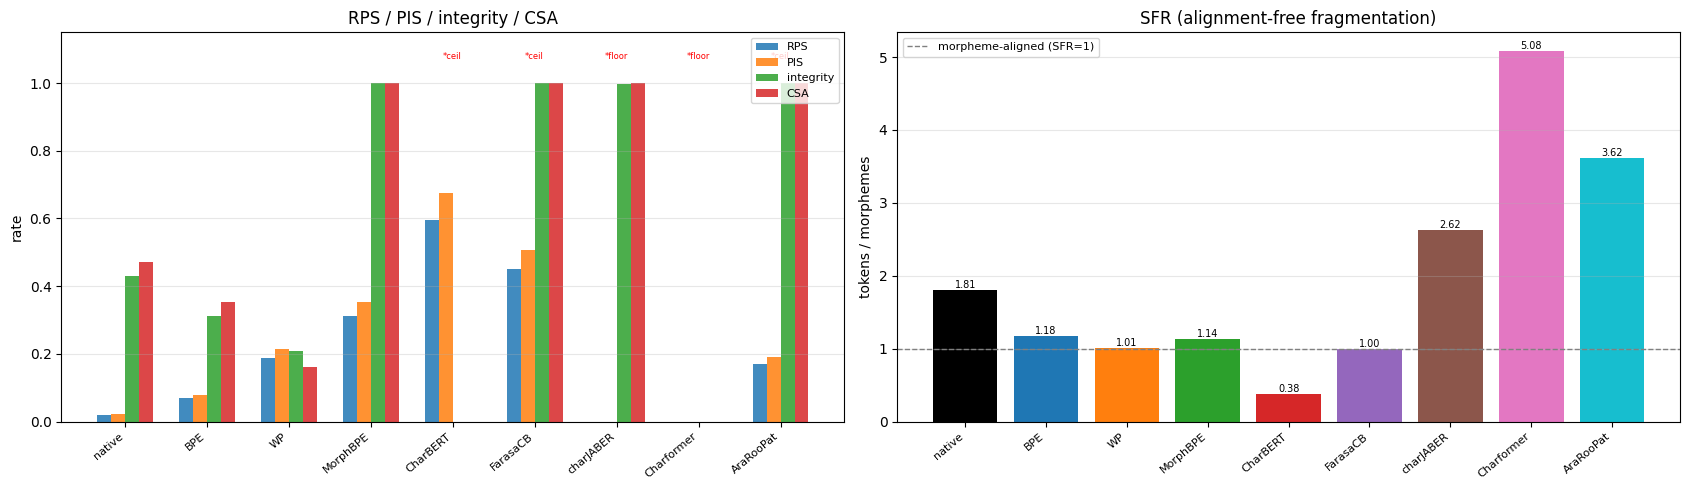

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left: grouped bars for the four 0-1 metrics.
ax = axes[0]
x = np.arange(len(TOKENIZERS))
width = 0.17
for i, col in enumerate(["RPS", "PIS", "integrity", "CSA"]):
    vals = morph_df[col].apply(lambda v: float(v) if v is not None and not (isinstance(v, float) and np.isnan(v)) else 0).values
    ax.bar(x + (i - 1.5) * width, vals, width, label=col, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([SHORT[t] for t in TOKENIZERS], rotation=40, ha="right", fontsize=8)
ax.set_ylim(0, 1.15); ax.set_ylabel("rate"); ax.set_title("RPS / PIS / integrity / CSA")
ax.legend(loc="upper right", fontsize=8); ax.grid(axis="y", alpha=0.3)
for ti, tok in enumerate(TOKENIZERS):
    if tok in RPS_MECHANICAL:
        ax.text(ti, 1.07, "*ceil", ha="center", fontsize=6, color="red")
    elif tok in RPS_FLOOR:
        ax.text(ti, 1.07, "*floor", ha="center", fontsize=6, color="red")

# Right: SFR.
ax = axes[1]
sfr = morph_df["SFR"].fillna(0).values.astype(float)
bars = ax.bar(range(len(TOKENIZERS)), sfr, color=[PALETTE[t] for t in TOKENIZERS])
ax.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="morpheme-aligned (SFR=1)")
ax.set_xticks(range(len(TOKENIZERS)))
ax.set_xticklabels([SHORT[t] for t in TOKENIZERS], rotation=40, ha="right", fontsize=8)
ax.set_title("SFR (alignment-free fragmentation)"); ax.set_ylabel("tokens / morphemes")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
for b, v in zip(bars, sfr):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout(); plt.show()

**Reading:**
- **native_llama** sits at SFR=1.81 -- over-fragments Arabic morphemes by 80%. This is the baseline cost of a multilingual BPE.
- **morpho_bpe_32k** is the standout: SFR~1.0 (morpheme-aligned by design via Farasa pre-segmentation).
- **SFR is the cleanest cross-family discriminator:** CharBERT ~0.5 (under-segments: 1 token per multi-morpheme word), BPE/WP ~1.2, native ~1.8, char-JABER ~2.8, AraRooPat ~3.4, Charformer ~5.1.
- `integrity`/`CSA` = `None` for Charformer: byte tokens can't align to Arabic-letter offsets -- **not measurable**.

## 5. Training dynamics

| Phase | Trains | Dataset | Loss |
|---|---|---|---|
| Phase 1 (embedding_alignment) | embed_tokens + lm_head only | arabic_squad | full-sequence CE |
| Phase 2 (warmup) | all params | arabic_squad | answer-only |
| Phase 3 (sft) | all params | tydiqa + arcd + arabic_squad_mcq | answer-only + early-stop |

**native_llama skips Phase 1** (pretrained embeddings are already aligned).

In [8]:
PHASES = ["embedding_alignment", "warmup", "sft"]

def per_phase(tok: str, ph: str, key: str):
    rec = RECORDS[tok]
    if not rec["ok"]:
        return None
    t = rec["training"].get(ph, {}) or {}
    if t.get("status") == "skipped":
        return None
    return t.get(key)


# Wall time.
wall = pd.DataFrame(
    {ph: [per_phase(t, ph, "wall_time_sec") for t in TRAINED_TOKENIZERS] for ph in PHASES},
    index=TRAINED_TOKENIZERS,
)
wall["TOTAL_min"] = wall.sum(axis=1, skipna=True) / 60.0

# Final train loss.
final_loss = pd.DataFrame(
    {ph: [per_phase(t, ph, "final_train_loss") for t in TRAINED_TOKENIZERS] for ph in PHASES},
    index=TRAINED_TOKENIZERS,
)

print("Wall time (seconds) + total in minutes:")
display(wall.style.apply(highlight_ref, axis=1).format("{:.1f}", na_rep="(skip)"))

print("\nFinal train loss per phase:")
display(final_loss.style.apply(highlight_ref, axis=1).format("{:.4f}", na_rep="(skip)"))

Wall time (seconds) + total in minutes:


,embedding_alignment,warmup,sft,TOTAL_min
native_llama,(skip),508.5,317.5,13.8
bpe_32k,371.8,496.2,349.4,20.3
wordpiece_32k,107.4,151.7,233.9,8.2
morpho_bpe_32k,95.1,120.0,214.7,7.2
character_bert,94.0,149.4,225.5,7.8
farasa_character_bert,82.8,129.3,205.2,7.0
char_jaber,63.2,114.5,167.7,5.8
araroopat,59.8,114.6,152.3,5.4



Final train loss per phase:


,embedding_alignment,warmup,sft
native_llama,(skip),2.5214,1.5989
bpe_32k,4.2707,1.3046,0.3789
wordpiece_32k,4.7287,1.2423,0.6742
morpho_bpe_32k,3.5786,0.9225,1.5267
character_bert,5.7538,5.0943,0.0080
farasa_character_bert,4.4229,4.5664,5.6152
char_jaber,2.4796,1.9956,1.9866
araroopat,1.6399,0.1523,0.1937


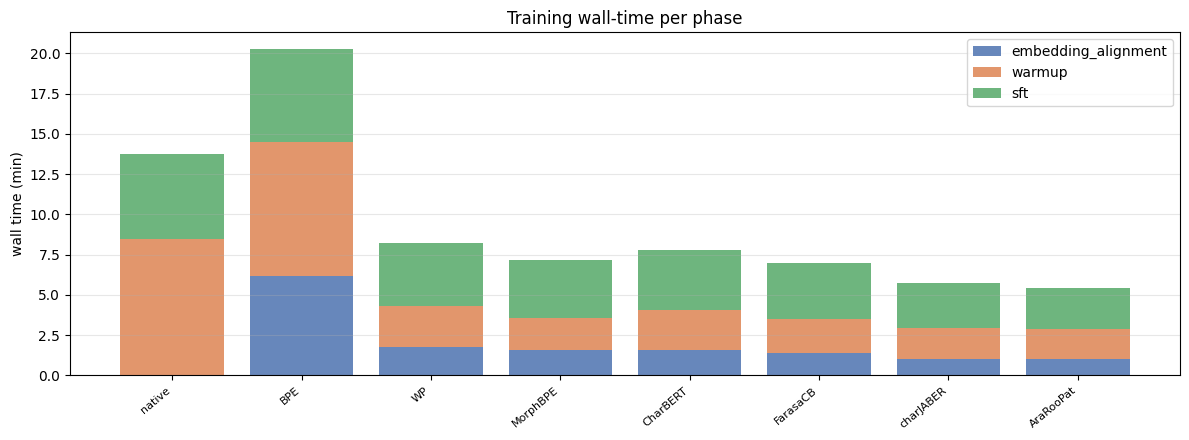

In [9]:
# Stacked bar of wall time.
fig, ax = plt.subplots(figsize=(12, 4.5))
bottom = np.zeros(len(TRAINED_TOKENIZERS))
phase_colors = {"embedding_alignment": "#4c72b0", "warmup": "#dd8452", "sft": "#55a868"}
for ph in PHASES:
    vals = wall[ph].fillna(0).values / 60.0
    ax.bar(range(len(TRAINED_TOKENIZERS)), vals, bottom=bottom, label=ph, color=phase_colors[ph], alpha=0.85)
    bottom += vals
ax.set_xticks(range(len(TRAINED_TOKENIZERS)))
ax.set_xticklabels([SHORT[t] for t in TRAINED_TOKENIZERS], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("wall time (min)"); ax.set_title("Training wall-time per phase")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

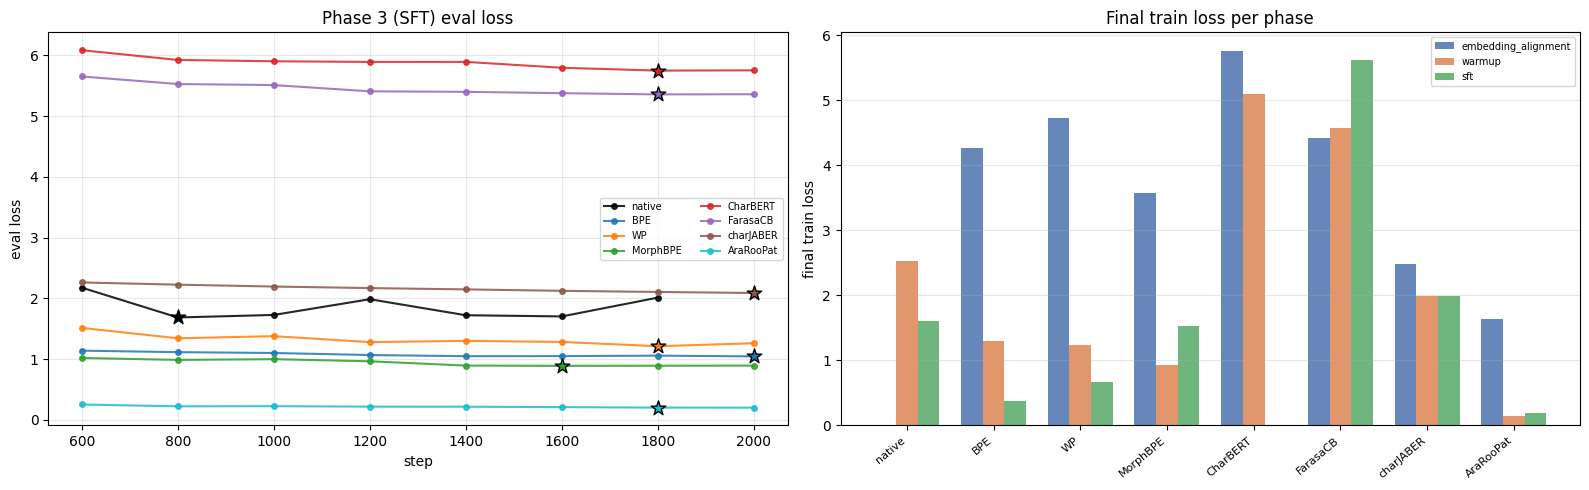

,early_stopped,best_eval_loss,best_eval_step
native_llama,True,1.6848,800
bpe_32k,False,1.0444,2000
wordpiece_32k,False,1.2115,1800
morpho_bpe_32k,False,0.8886,1600
character_bert,False,5.7476,1800
farasa_character_bert,False,5.3559,1800
char_jaber,False,2.0878,2000
araroopat,False,0.2015,1800


In [10]:
# Phase 3 eval-loss curves.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Phase 3 eval-loss.
ax = axes[0]
for tok in TRAINED_TOKENIZERS:
    rec = RECORDS[tok]
    if not rec["ok"]: continue
    sft = rec["training"].get("sft", {}) or {}
    if sft.get("status") == "skipped": continue
    evals = sft.get("eval_losses") or []
    if not evals: continue
    steps = [int(s) for s, _ in evals]
    losses = [float(l) for _, l in evals]
    best = sft.get("best_eval_step")
    ax.plot(steps, losses, marker="o", ms=4, linewidth=1.5, label=SHORT[tok], color=PALETTE[tok], alpha=0.85)
    if best is not None and sft.get("best_eval_loss") is not None:
        ax.scatter([best], [sft["best_eval_loss"]], marker="*", s=120, color=PALETTE[tok], edgecolor="black", zorder=5)
ax.set_xlabel("step"); ax.set_ylabel("eval loss")
ax.set_title("Phase 3 (SFT) eval loss"); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

# Right: final train loss comparison across all 3 phases.
ax = axes[1]
x = np.arange(len(TRAINED_TOKENIZERS))
w = 0.25
for i, ph in enumerate(PHASES):
    vals = final_loss[ph].fillna(0).values
    ax.bar(x + (i - 1) * w, vals, w, label=ph, color=phase_colors[ph], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([SHORT[t] for t in TRAINED_TOKENIZERS], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("final train loss"); ax.set_title("Final train loss per phase")
ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

# Early-stop table.
es = pd.DataFrame({
    "early_stopped":  [per_phase(t, "sft", "early_stopped") for t in TRAINED_TOKENIZERS],
    "best_eval_loss": [per_phase(t, "sft", "best_eval_loss") for t in TRAINED_TOKENIZERS],
    "best_eval_step": [per_phase(t, "sft", "best_eval_step") for t in TRAINED_TOKENIZERS],
}, index=TRAINED_TOKENIZERS)
display(es)

**Reading:**
- **None of the 8 trained tokenizers triggered early-stop** -- Phase 3 ran to the full 2000-step budget for every cell.
- native_llama's Phase 1 is skipped (pretrained embeddings); its Phase 2 train loss is higher (2.52 vs ~1.3 for from-scratch) because from-scratch tokenizers' embedding alignment drifts the loss landscape.
- `char_jaber` and `farasa_character_bert` have the longest wall times due to longer sequences (char-level / morpheme-level).

## 6. Downstream accuracy

### 6.1 Per-task accuracy with delta vs native_llama

In [11]:
acc_rows = []
for tok in TOKENIZERS:
    rec = RECORDS[tok]
    for task in TASKS:
        if not rec["ok"]:
            acc_rows.append({"tokenizer": tok, "task": task, "accuracy_pmi": None, "accuracy_char_norm": None,
                             "num_samples": None, "inference_sec": None})
            continue
        d = rec["downstream"].get(task, {}) or {}
        acc_rows.append({
            "tokenizer": tok, "task": task,
            "accuracy_pmi":       d.get("accuracy_pmi"),
            "accuracy_char_norm": d.get("accuracy_char_norm"),
            "num_samples":        d.get("num_samples"),
            "inference_sec":      d.get("inference_time_sec"),
        })

acc_df = pd.DataFrame(acc_rows)
pivot_pmi = acc_df.pivot(index="tokenizer", columns="task", values="accuracy_pmi").reindex(TOKENIZERS)[TASKS]
pivot_cn  = acc_df.pivot(index="tokenizer", columns="task", values="accuracy_char_norm").reindex(TOKENIZERS)[TASKS]
pivot_t   = acc_df.pivot(index="tokenizer", columns="task", values="inference_sec").reindex(TOKENIZERS)[TASKS]

# Delta.
ref_row = pivot_pmi.loc["native_llama"]
delta_pmi = pivot_pmi.subtract(ref_row, axis=1)
delta_pmi["mean_delta"] = delta_pmi.mean(axis=1)

print("Accuracy (PMI) -- the default scoring:")
display(pivot_pmi.style.apply(highlight_ref, axis=1).format("{:.4f}", na_rep="--"))

print("\nDelta vs native_llama (green = improvement, red = regression):")
display(delta_pmi.style
    .applymap(color_delta)
    .apply(highlight_ref, axis=1)
    .format("{:+.4f}", na_rep="--"))

print("\nAccuracy (char-norm) -- legacy scoring:")
display(pivot_cn.style.apply(highlight_ref, axis=1).format("{:.4f}", na_rep="--"))

print("\nInference time (seconds):")
display(pivot_t.style.apply(highlight_ref, axis=1).format("{:.1f}", na_rep="--"))

Accuracy (PMI) -- the default scoring:


task,acva,alghafa,arabic_exam
tokenizer,,,
native_llama,0.4570,0.3641,0.3294
bpe_32k,0.5222,0.3759,0.3175
wordpiece_32k,0.5958,0.3720,0.2653
morpho_bpe_32k,0.4060,0.3850,0.3136
character_bert,0.5960,0.3697,0.2655
farasa_character_bert,0.5960,0.3709,0.2879
char_jaber,0.5960,0.3765,0.2888
charformer,--,--,--
araroopat,0.5333,0.3726,0.2735



Delta vs native_llama (green = improvement, red = regression):


task,acva,alghafa,arabic_exam,mean_delta
tokenizer,,,,
native_llama,+0.0000,+0.0000,+0.0000,+0.0000
bpe_32k,+0.0652,+0.0118,-0.0119,+0.0217
wordpiece_32k,+0.1388,+0.0079,-0.0641,+0.0275
morpho_bpe_32k,-0.0510,+0.0209,-0.0158,-0.0153
character_bert,+0.1390,+0.0056,-0.0639,+0.0269
farasa_character_bert,+0.1390,+0.0068,-0.0415,+0.0348
char_jaber,+0.1390,+0.0124,-0.0406,+0.0369
charformer,--,--,--,--
araroopat,+0.0763,+0.0085,-0.0559,+0.0096



Accuracy (char-norm) -- legacy scoring:


task,acva,alghafa,arabic_exam
tokenizer,,,
native_llama,0.5889,0.3668,0.3060
bpe_32k,0.5945,0.3843,0.2858
wordpiece_32k,0.4042,0.3715,0.2890
morpho_bpe_32k,0.5757,0.3674,0.3172
character_bert,0.4040,0.3704,0.2816
farasa_character_bert,0.4040,0.3702,0.3110
char_jaber,0.4040,0.3784,0.3129
charformer,--,--,--
araroopat,0.5960,0.3717,0.2783



Inference time (seconds):


task,acva,alghafa,arabic_exam
tokenizer,,,
native_llama,445.7,1330.6,1017.2
bpe_32k,434.4,1431.6,882.9
wordpiece_32k,402.0,1283.1,868.1
morpho_bpe_32k,418.8,1376.5,914.2
character_bert,428.4,1405.2,939.9
farasa_character_bert,435.7,1462.1,959.4
char_jaber,399.7,989.7,815.2
charformer,--,--,--
araroopat,413.4,1055.6,852.4


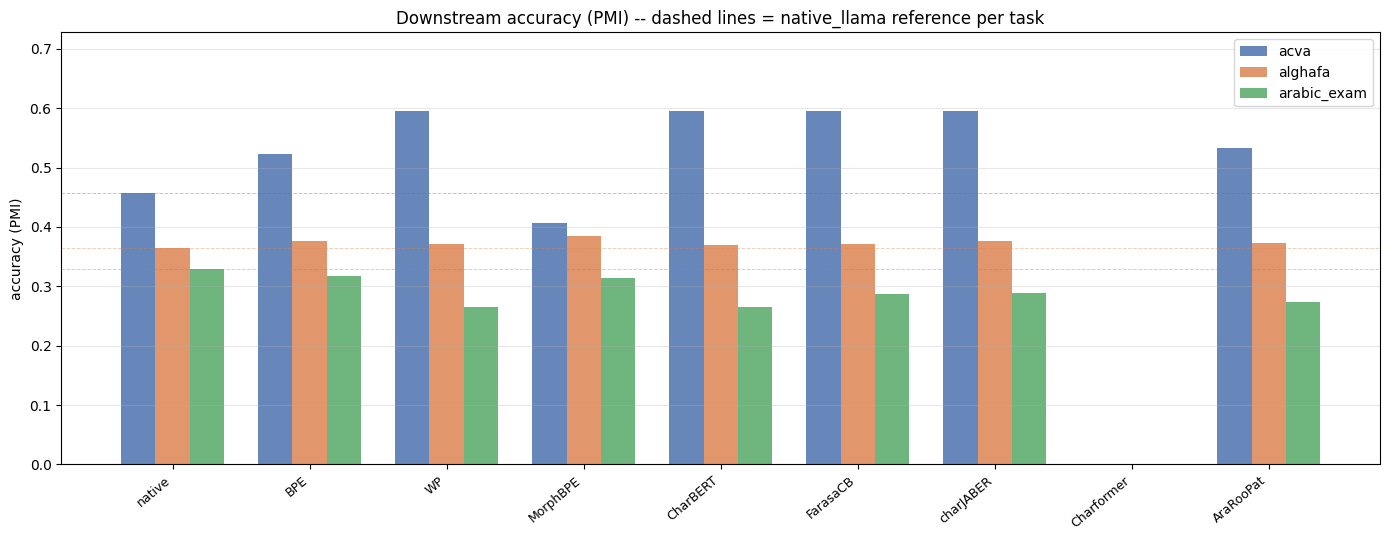

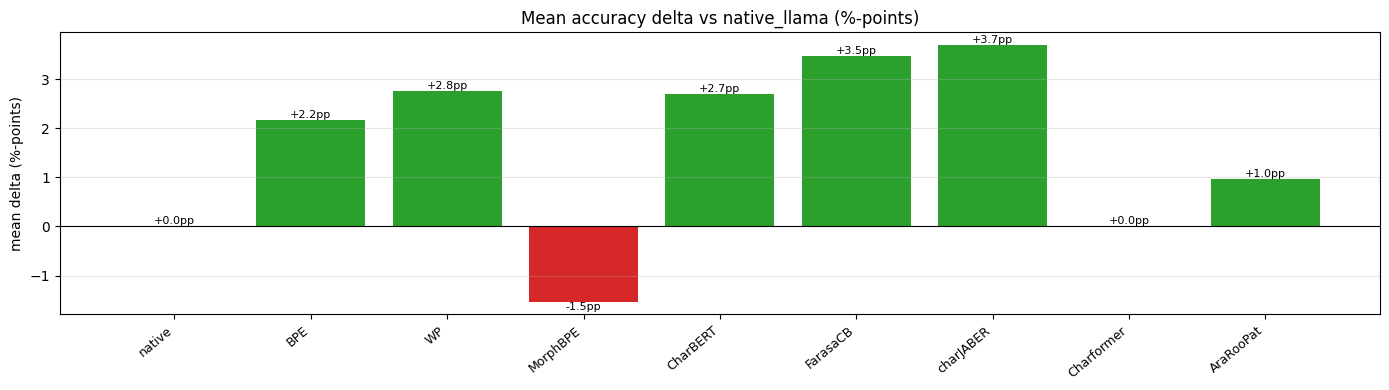

In [12]:
# Accuracy bar chart with native_llama reference lines.
fig, ax = plt.subplots(figsize=(14, 5.5))
x = np.arange(len(TOKENIZERS))
width = 0.25
task_colors = ["#4c72b0", "#dd8452", "#55a868"]
for i, task in enumerate(TASKS):
    vals = pivot_pmi[task].fillna(0).values
    ax.bar(x + (i - 1) * width, vals, width, label=task, color=task_colors[i], alpha=0.85)
    # Reference line per task.
    ref = pivot_pmi.loc["native_llama", task]
    if ref is not None and not np.isnan(ref):
        ax.axhline(ref, color=task_colors[i], linestyle="--", linewidth=0.7, alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels([SHORT[t] for t in TOKENIZERS], rotation=40, ha="right", fontsize=9)
ymax = float(np.nanmax(pivot_pmi.values)) if pivot_pmi.notna().any().any() else 0.7
ax.set_ylim(0, max(ymax, 0.65) * 1.12)
ax.set_ylabel("accuracy (PMI)"); ax.set_title("Downstream accuracy (PMI) -- dashed lines = native_llama reference per task")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Delta waterfall.
fig, ax = plt.subplots(figsize=(14, 4))
mean_deltas = delta_pmi["mean_delta"].reindex(TOKENIZERS).fillna(0)
colors = ["#2ca02c" if v > 0.005 else "#d62728" if v < -0.005 else "#999999" for v in mean_deltas.values]
ax.bar(range(len(TOKENIZERS)), mean_deltas.values * 100, color=colors, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(TOKENIZERS)))
ax.set_xticklabels([SHORT[t] for t in TOKENIZERS], rotation=40, ha="right", fontsize=9)
ax.set_ylabel("mean delta (%-points)"); ax.set_title("Mean accuracy delta vs native_llama (%-points)")
for i, v in enumerate(mean_deltas.values):
    ax.text(i, v * 100, f"{v*100:+.1f}pp", ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

**Key observations:**

- **4 tokenizers collapse on ACVA** (`wordpiece_32k`, `char_jaber`, `character_bert`, `farasa_character_bert`): identical PMI accuracy (~0.596) down to 4 decimals, identical per-sub-config numbers. This is NOT genuine improvement -- it's a UNK artifact (see Section 7 for the smoking gun).
- **bpe_32k** genuinely beats native_llama on ACVA (+0.065) and Alghafa (+0.012) but slightly regresses on Arabic-Exam (-0.012). Best overall non-collapsed tokenizer.
- **araroopat** shows the strongest ACVA gain (+0.076) and is competitive on Alghafa (+0.009), but regresses on Arabic-Exam (-0.056).
- **morpho_bpe_32k** is below random on ACVA (0.406 < 0.50) -- Farasa pre-segmentation damages the prompt format.
- **Arabic-Exam regresses for ALL from-scratch tokenizers** -- this 4-way MCQ across 41 subjects rewards pretrained knowledge-encoding that from-scratch embeddings can't recover in 3 phases.

### 6.2 Per-sub-config breakdown -- Alghafa

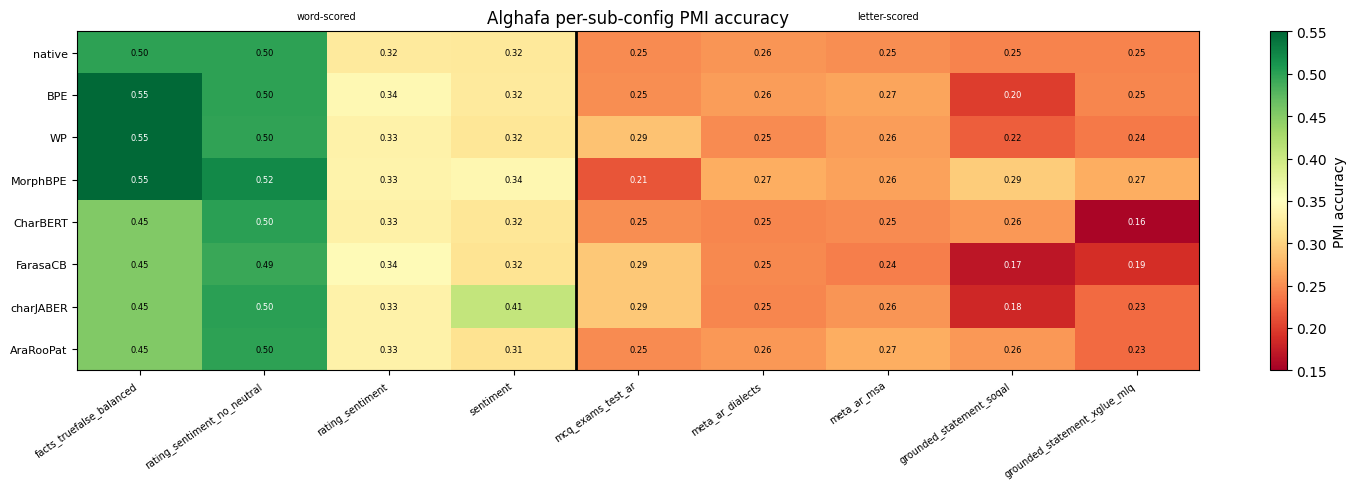

In [13]:
def per_subcfg(tok: str, task: str) -> dict:
    rec = RECORDS[tok]
    if not rec["ok"]: return {}
    psa = (rec["downstream"].get(task, {}) or {}).get("per_subconfig_accuracy") or {}
    return {sub: m.get("accuracy_pmi", m.get("accuracy")) for sub, m in psa.items()}


alghafa_psa = pd.DataFrame({tok: per_subcfg(tok, "alghafa") for tok in TRAINED_TOKENIZERS}).T

WORD_SCORED = [
    "multiple_choice_facts_truefalse_balanced_task",
    "multiple_choice_rating_sentiment_no_neutral_task",
    "multiple_choice_rating_sentiment_task",
    "multiple_choice_sentiment_task",
]
LETTER_SCORED = sorted([c for c in alghafa_psa.columns if c not in WORD_SCORED])
ordered_cols = [c for c in WORD_SCORED if c in alghafa_psa.columns] + LETTER_SCORED
alghafa_psa = alghafa_psa[ordered_cols]

# Heatmap.
fig, ax = plt.subplots(figsize=(15, 5))
data = alghafa_psa.values.astype(float)
im = ax.imshow(data, cmap="RdYlGn", aspect="auto", vmin=0.15, vmax=0.55)
n_ws = sum(1 for c in ordered_cols if c in WORD_SCORED)
ax.set_xticks(range(len(ordered_cols)))
short_cols = [c.replace("multiple_choice_", "").replace("_task", "")[:28] for c in ordered_cols]
ax.set_xticklabels(short_cols, rotation=35, ha="right", fontsize=7)
ax.set_yticks(range(len(alghafa_psa.index)))
ax.set_yticklabels([SHORT[t] for t in alghafa_psa.index], fontsize=8)
if n_ws > 0:
    ax.axvline(n_ws - 0.5, color="black", linewidth=2)
    ax.text(n_ws / 2 - 0.5, -0.8, "word-scored", ha="center", fontsize=7)
    ax.text(n_ws + (len(ordered_cols) - n_ws) / 2 - 0.5, -0.8, "letter-scored", ha="center", fontsize=7)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if v < 0.22 or v > 0.50 else "black")
plt.colorbar(im, ax=ax, label="PMI accuracy")
ax.set_title("Alghafa per-sub-config PMI accuracy"); plt.tight_layout(); plt.show()

### 6.3 MEI -- Morphological Efficiency Index

`MEI = (accuracy x RPS x compression x N_eval) / inference_time`

**Caveat**: tokenizers at the RPS ceiling (CharBERT, AraRooPat) or floor (char-JABER) produce mechanically biased MEI.

task,acva,alghafa,arabic_exam
native,0.471,0.321,0.239
BPE,3.274,1.680,1.520
WP,10.451,4.804,3.344
MorphBPE,8.340,5.653,4.579
CharBERT *,43.641,19.393,13.752
FarasaCB *,17.530,7.639,5.969
charJABER (floor),0.000,0.000,0.000
Charformer (floor),--,--,--
AraRooPat *,2.013,1.294,0.777


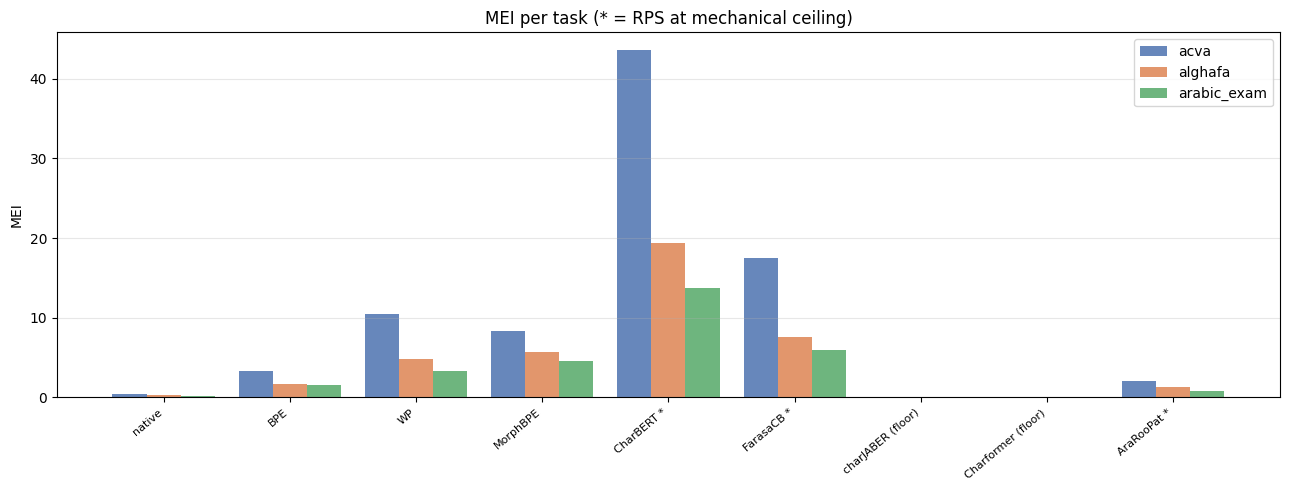

In [14]:
mei_rows = []
for tok in TOKENIZERS:
    rec = RECORDS[tok]
    for task in TASKS:
        m = (rec.get("mei", {}) or {}).get(task) if rec["ok"] else None
        mei_rows.append({"tokenizer": tok, "task": task, "MEI": m.get("mei") if m else None})
mei_pivot = pd.DataFrame(mei_rows).pivot(index="tokenizer", columns="task", values="MEI").reindex(TOKENIZERS)[TASKS]

def flag_label(t):
    if t in RPS_MECHANICAL: return f"{SHORT[t]} *"
    if t in RPS_FLOOR:      return f"{SHORT[t]} (floor)"
    return SHORT[t]

mei_print = mei_pivot.copy()
mei_print.index = [flag_label(t) for t in mei_print.index]
display(mei_print.style.format("{:.3f}", na_rep="--"))

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(TOKENIZERS))
for i, task in enumerate(TASKS):
    vals = mei_pivot[task].fillna(0).values
    ax.bar(x + (i - 1) * 0.27, vals, 0.27, label=task, color=task_colors[i], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([flag_label(t) for t in TOKENIZERS], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("MEI"); ax.set_title("MEI per task (* = RPS at mechanical ceiling)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 7. UNK analysis

### 7.1 Intrinsic UNK (corpus encoding)

Every whitespace word in the eval split is encoded; words producing >=1 UNK are collected.

> native_llama's experiment did not have `intrinsic_unk_report: true`, so no CSV is available.

,unique_UNK_words,total_UNK_tokens
tokenizer,,
native_llama,0,0
bpe_32k,0,0
wordpiece_32k,24,49
morpho_bpe_32k,23,53
character_bert,"282,350","474,854"
farasa_character_bert,"63,302","78,818"
char_jaber,23,53
charformer,0,0
araroopat,"22,880","206,361"


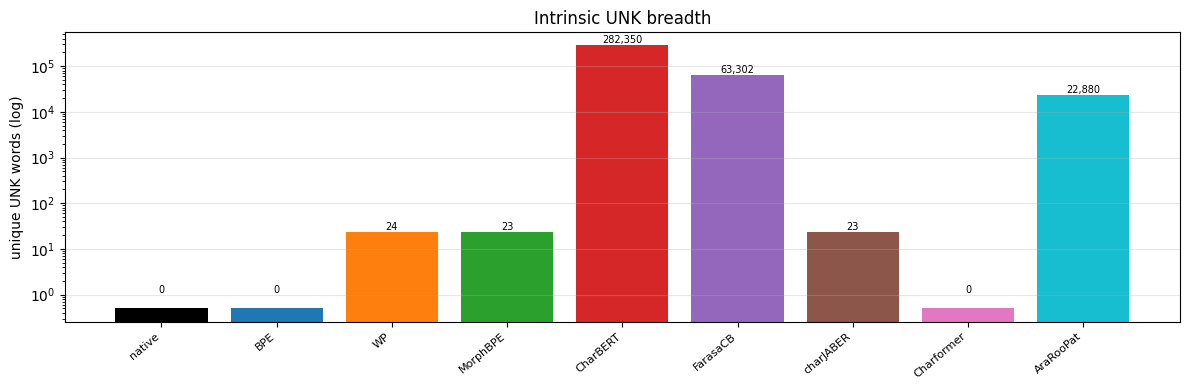

In [15]:
def load_intrinsic_unks(tok: str) -> pd.DataFrame:
    p = (NATIVE_DIR if tok == "native_llama" else SWEEP_DIR / tok) / "intrinsic_unks.csv"
    if not p.exists(): return pd.DataFrame()
    try: return pd.read_csv(p, encoding="utf-8-sig")
    except pd.errors.EmptyDataError: return pd.DataFrame()


intr_unk_frames = {tok: load_intrinsic_unks(tok) for tok in TOKENIZERS}

intr_unk_summary = pd.DataFrame([{
    "tokenizer": tok,
    "unique_UNK_words":  len(df),
    "total_UNK_tokens":  int(df["unk_token_count"].sum()) if not df.empty and "unk_token_count" in df.columns else 0,
} for tok, df in [(t, intr_unk_frames[t]) for t in TOKENIZERS]]).set_index("tokenizer")

display(intr_unk_summary.style.apply(highlight_ref, axis=1).format("{:,}"))

fig, ax = plt.subplots(figsize=(12, 4))
vals = intr_unk_summary["unique_UNK_words"].clip(lower=0.5)
ax.bar(range(len(TOKENIZERS)), vals.values, color=[PALETTE[t] for t in vals.index])
ax.set_yscale("log"); ax.set_xticks(range(len(TOKENIZERS)))
ax.set_xticklabels([SHORT[t] for t in vals.index], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("unique UNK words (log)"); ax.set_title("Intrinsic UNK breadth")
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(intr_unk_summary["unique_UNK_words"].values):
    ax.text(i, max(v, 1), f"{v:,}", ha="center", va="bottom", fontsize=7)
plt.tight_layout(); plt.show()

In [16]:
# Top-10 intrinsic UNK words per tokenizer.
# Words are shown as-is (Jupyter HTML renders all Unicode including CJK).
# A "script" column classifies each word to aid interpretation.

for tok in TOKENIZERS:
    df = intr_unk_frames[tok]
    if df.empty:
        print(f"  {tok}: no UNK words")
        print()
        continue

    n_show = min(10, len(df))
    top = df.nlargest(n_show, "unk_token_count")[["word", "unk_token_count", "total_token_count"]].copy()
    top.insert(1, "script", top["word"].apply(detect_script))
    top = top.reset_index(drop=True)
    top.index = top.index + 1
    top.index.name = "#"

    print(f"  {tok} ({len(df):,} unique UNK words, top {n_show}):")
    display(top)
    print()

  native_llama: no UNK words

  bpe_32k: no UNK words

  wordpiece_32k (24 unique UNK words, top 10):


,word,script,unk_token_count,total_token_count
#,,,,
1,◄,Symbol,20,60
2,"""鮨""",Mixed(CJK/Kana+Symbol),6,30
3,"""鮓""",Mixed(CJK/Kana+Symbol),2,10
4,"""醢""",Mixed(CJK/Kana+Symbol),1,5
5,"""雑鮨五斗",Mixed(CJK/Kana+Symbol),1,4
6,"""鮓""،",Mixed(Arabic+CJK/Kana+Symbol),1,5
7,"""鮓滓也",Mixed(CJK/Kana+Symbol),1,4
8,(فو-服务),Mixed(Arabic+CJK/Kana+Symbol),1,7
9,(けぬき寿し),Mixed(CJK/Kana+Symbol),1,5



  morpho_bpe_32k (23 unique UNK words, top 10):


,word,script,unk_token_count,total_token_count
#,,,,
1,◄,Symbol,20,60
2,"""鮨""",Mixed(CJK/Kana+Symbol),6,30
3,"""鮓""",Mixed(CJK/Kana+Symbol),2,10
4,"""鮓滓也",Mixed(CJK/Kana+Symbol),2,6
5,(守貞謾稿),Mixed(CJK/Kana+Symbol),2,8
6,«鮓滓,Mixed(CJK/Kana+Symbol),2,5
7,以塩米醸之加葅,CJK/Kana,2,9
8,"熟而食之也""،",Mixed(Arabic+CJK/Kana+Symbol),2,9
9,"""醢""",Mixed(CJK/Kana+Symbol),1,5



  character_bert (282,350 unique UNK words, top 10):


...

,word,script,unk_token_count,total_token_count
#,,,,
1,غاركس,Arabic,45,135
2,ساكب,Arabic,44,132
3,Rover,Latin,36,108
4,دريسلر,Arabic,35,105
5,هاريغريفز,Arabic,32,96
6,ماريانيلا,Arabic,30,90
7,تريستر,Arabic,29,87
8,كريستيفا,Arabic,29,87
9,تولدو,Arabic,27,81



  char_jaber (23 unique UNK words, top 10):


,word,script,unk_token_count,total_token_count
#,,,,
1,◄,Symbol,20,60
2,"""鮨""",Mixed(CJK/Kana+Symbol),6,30
3,"""鮓""",Mixed(CJK/Kana+Symbol),2,10
4,"""鮓滓也",Mixed(CJK/Kana+Symbol),2,6
5,(守貞謾稿),Mixed(CJK/Kana+Symbol),2,8
6,«鮓滓,Mixed(CJK/Kana+Symbol),2,5
7,以塩米醸之加葅,CJK/Kana,2,9
8,"熟而食之也""،",Mixed(Arabic+CJK/Kana+Symbol),2,9
9,"""醢""",Mixed(CJK/Kana+Symbol),1,5



  charformer: no UNK words

  araroopat (22,880 unique UNK words, top 10):


,word,script,unk_token_count,total_token_count
#,,,,
1,على,Arabic,43571,217855
2,الى,Arabic,32794,229558
3,حتى,Arabic,5367,26835
4,‏,Other,2330,6990
5,اخرى,Arabic,2283,18264
6,الاولى,Arabic,1848,18480
7,احدى,Arabic,1571,12568
8,الاخرى,Arabic,1404,14040
9,وعلى,Arabic,1241,7446


**Reading:**
- **character_bert (282k UNK words)**: the top entries are proper nouns / rare Arabic words (`ايومي`, `لوغوسي`, `لوكاكو` -- transliterated foreign names). The 50k word vocab simply can't cover the long tail.
- **farasa_character_bert (63k)**: similar pattern at the morpheme level.
- **araroopat (23k)**: the top entries are common Arabic words like `على` and `الى` -- these are particles that CAMeL routes to the LIT fallback path because they lack triliteral roots.
- **Small-UNK tokenizers** (BPE, WordPiece, MorphoBPE, char-JABER): only CJK ideographs and mathematical symbols that appeared in the Arabic corpus (articles about Japanese cuisine, Chinese technology, etc.). The `script` column confirms: all non-Arabic.

### 7.2 Downstream UNK (prompts & continuations)

Per LightEval task: every prompt + continuation scanned for UNK-producing words.

**This is the critical diagnostic table** -- it reveals whether the evaluation surface itself is poisoned by UNKs.

In [17]:
def load_downstream_unks(tok: str, task: str) -> pd.DataFrame:
    p = (NATIVE_DIR if tok == "native_llama" else SWEEP_DIR / tok) / "unk_reports" / f"{task}_unks.csv"
    if not p.exists(): return pd.DataFrame()
    try: return pd.read_csv(p, encoding="utf-8-sig")
    except pd.errors.EmptyDataError: return pd.DataFrame()


ds_rows = []
for tok in TOKENIZERS:
    for task in TASKS:
        df = load_downstream_unks(tok, task)
        ds_rows.append({
            "tokenizer": tok, "task": task,
            "unique_UNK_words": len(df),
            "total_UNK_tokens": int(df["unk_token_count"].sum()) if not df.empty and "unk_token_count" in df.columns else 0,
        })
ds_df = pd.DataFrame(ds_rows)
ds_pivot = ds_df.pivot(index="tokenizer", columns="task", values="unique_UNK_words").reindex(TOKENIZERS)[TASKS]
ds_pivot_sum = ds_df.pivot(index="tokenizer", columns="task", values="total_UNK_tokens").reindex(TOKENIZERS)[TASKS]

print("Unique UNK words per (tokenizer, task):")
display(ds_pivot.style.apply(highlight_ref, axis=1).format("{:,.0f}", na_rep="(no report)"))

print("\nTotal UNK token count per (tokenizer, task):")
display(ds_pivot_sum.style.apply(highlight_ref, axis=1).format("{:,.0f}", na_rep="(no report)"))

Unique UNK words per (tokenizer, task):


task,acva,alghafa,arabic_exam
tokenizer,,,
native_llama,0,0,0
bpe_32k,0,15,0
wordpiece_32k,"1,306","11,605","11,722"
morpho_bpe_32k,0,125,126
character_bert,"3,161","55,227","33,816"
farasa_character_bert,228,"17,685","7,107"
char_jaber,"1,306","11,599","11,711"
charformer,0,0,0
araroopat,84,"5,030","3,101"



Total UNK token count per (tokenizer, task):


task,acva,alghafa,arabic_exam
tokenizer,,,
native_llama,0,0,0
bpe_32k,0,39,0
wordpiece_32k,"29,018","256,830","200,161"
morpho_bpe_32k,0,312,"2,258"
character_bert,"43,029","471,705","325,180"
farasa_character_bert,"10,209","77,399","39,842"
char_jaber,"29,209","262,107","396,402"
charformer,0,0,0
araroopat,"2,028","39,131","21,441"


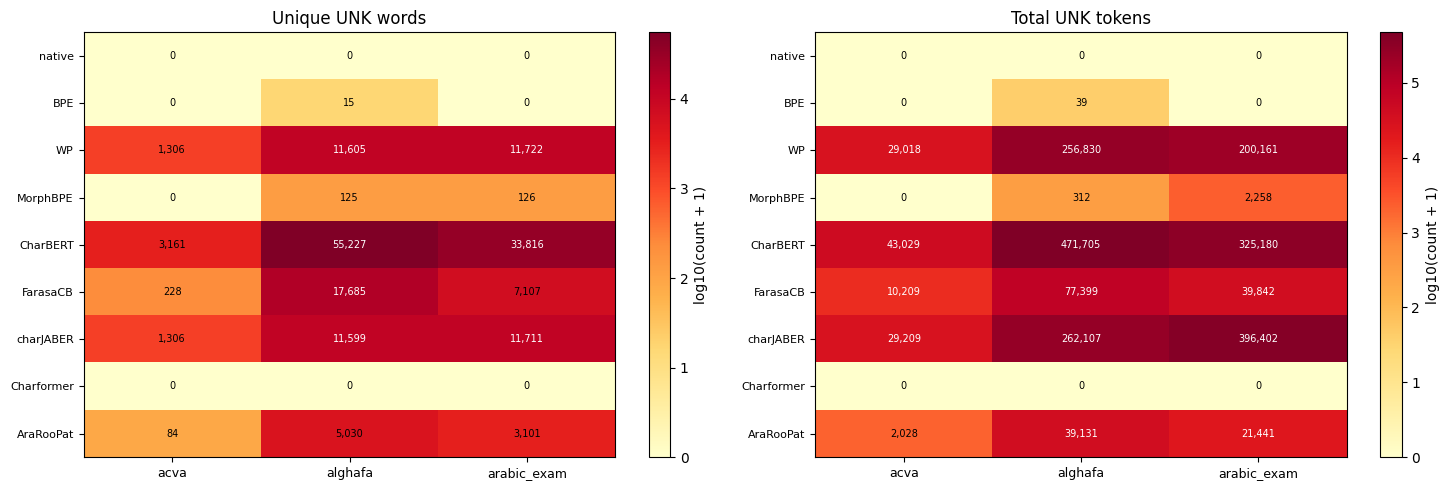

In [18]:
# Heatmap.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, data_df, title in zip(axes, [ds_pivot, ds_pivot_sum],
                               ["Unique UNK words", "Total UNK tokens"]):
    data = data_df.fillna(0).values.astype(float)
    data_log = np.log10(data + 1)
    im = ax.imshow(data_log, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(data_df.columns))); ax.set_xticklabels(data_df.columns, fontsize=9)
    ax.set_yticks(range(len(data_df.index)))
    ax.set_yticklabels([SHORT[t] for t in data_df.index], fontsize=8)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = int(data[i, j])
            ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=7,
                    color="white" if data_log[i, j] > 4 else "black")
    plt.colorbar(im, ax=ax, label="log10(count + 1)")
    ax.set_title(title)
plt.tight_layout(); plt.show()

In [19]:
# Top-5 downstream UNK words per (tokenizer, task) -- proper styled DataFrames.

for tok in TOKENIZERS:
    any_shown = False
    for task in TASKS:
        df = load_downstream_unks(tok, task)
        if df.empty or len(df) == 0:
            continue
        top = df.nlargest(min(5, len(df)), "unk_token_count").copy()
        cols = ["word", "unk_token_count"]
        if "num_examples_seen_in" in top.columns:
            cols.append("num_examples_seen_in")
        if "source_fields" in top.columns:
            cols.append("source_fields")
        top = top[cols].copy()
        top.insert(1, "script", top["word"].apply(detect_script))
        if "source_fields" in top.columns:
            top["source_fields"] = top["source_fields"].astype(str).str[:45]
        top = top.reset_index(drop=True)
        top.index = top.index + 1
        top.index.name = "#"

        print(f"  {tok} / {task} ({len(df):,} unique UNK words):")
        display(top)
        any_shown = True
    if any_shown:
        print()

  bpe_32k / alghafa (15 unique UNK words):


,word,script,unk_token_count,num_examples_seen_in,source_fields
#,,,,,
1,ههههههههههههه󾌴󾌴󾌴󾌴󾌴󾌴󾌴,Mixed(Arabic+Other),7,1,prompt
2,󾌴󾌴󾌴󾌴󾌴,Other,5,1,prompt
3,󾍁󾍁󾌯󾌯?حكتلو_البنت:,Mixed(Arabic+Latin+Other+Symbol),4,1,prompt
4,ههههههههه󾌰󾌰󾌰,Mixed(Arabic+Other),3,1,prompt
5,󾌴󾌴󾌴,Other,3,1,prompt



  wordpiece_32k / acva (1,306 unique UNK words):


,word,script,unk_token_count,num_examples_seen_in,source_fields
#,,,,,
1,الإجابة:,Mixed(Arabic+Symbol),8998,8998,prompt
2,خطأ,Arabic,8998,8998,continuation_1
3,يُفضل,Arabic,383,383,prompt
4,يُعتبر,Arabic,356,356,prompt
5,الإمبراطورية,Arabic,348,348,prompt


  wordpiece_32k / alghafa (11,605 unique UNK words):


...

,word,script,unk_token_count,num_examples_seen_in,source_fields
#,,,,,
1,على,Arabic,1327,1310,prompt
2,إلى,Arabic,189,180,prompt
3,الموسيقى,Arabic,136,127,prompt
4,الوسطى,Arabic,32,32,prompt
5,الوسطى.,Mixed(Arabic+Symbol),31,31,prompt


  araroopat / alghafa (5,030 unique UNK words):


,word,script,unk_token_count,num_examples_seen_in,source_fields
#,,,,,
1,على,Arabic,11412,4871,continuation_0|continuation_1|contin...
2,إلى,Arabic,3313,2001,continuation_0|continuation_1|contin...
3,حتى,Arabic,961,814,continuation_0|continuation_1|contin...
4,“فندق,Mixed(Arabic+Symbol),557,557,prompt
5,مستوى,Arabic,426,322,continuation_0|continuation_1|contin...


  araroopat / arabic_exam (3,101 unique UNK words):


,word,script,unk_token_count,num_examples_seen_in,source_fields
#,,,,,
1,على,Arabic,3659,2625,prompt
2,إلى,Arabic,1954,1147,prompt
3,إِلَى,Arabic,742,303,prompt
4,فى,Arabic,670,467,prompt
5,عَلَى,Arabic,480,255,prompt


**The smoking gun -- ACVA prompt-suffix UNK collapse:**

| Tokenizer | `الإجابة:` is UNK on ACVA? | `خطأ` is UNK? | ACVA PMI | Collapsed? |
|---|---|---|---|---|
| native_llama | (no report) | (no report) | 0.457 | -- |
| bpe_32k | **no** | no | 0.522 | no |
| wordpiece_32k | **yes** (8998 rows) | **yes** (8998) | 0.596 | **yes** |
| morpho_bpe_32k | no | no | 0.406 | no |
| character_bert | yes | yes | 0.596 | **yes** |
| farasa_character_bert | yes | yes | 0.596 | **yes** |
| char_jaber | yes | yes | 0.596 | **yes** |
| araroopat | no | no | 0.533 | no |

When `الإجابة:` (the prompt answer-cue suffix) encodes as UNK, the model can't condition on it.
When `خطأ` (= "false", one of ACVA's two answer words) is also UNK, the model can't even score it.
Result: flat distribution -> PMI cancels the prior -> all four tokenizers pick the same answer on every row -> identical accuracy.

**For `wordpiece_32k`**: the colon `:` is not in WordPiece's vocab as part of `الإجابة:`, so the whole word becomes UNK.
**For `char_jaber`**: similarly, `الإجابة:` as a word (with trailing colon) triggers the UNK path.
**For `character_bert`/`farasa_character_bert`**: their output heads don't include compound-with-punctuation entries.

## 8. Failure analysis -- confidence margins

In [20]:
def load_failures(tok: str, task: str) -> pd.DataFrame:
    p = (NATIVE_DIR if tok == "native_llama" else SWEEP_DIR / tok) / "failure_reports" / f"{task}_accuracy_failures.csv"
    if not p.exists(): return pd.DataFrame()
    try: return pd.read_csv(p, encoding="utf-8-sig")
    except pd.errors.EmptyDataError: return pd.DataFrame()


fail_margins = {}
fail_rows = []
for tok in TRAINED_TOKENIZERS:
    for task in TASKS:
        df = load_failures(tok, task)
        n = len(df)
        margins = df.get("score_pmi_margin", df.get("score_margin", pd.Series(dtype=float))).dropna().values
        fail_margins[(tok, task)] = margins
        fail_rows.append({
            "tokenizer": tok, "task": task,
            "wrong_rows": n,
            "error_rate_%": round(n / pivot_pmi.loc[tok, task] * (1 - pivot_pmi.loc[tok, task]) if pivot_pmi.loc[tok, task] else 0, 1) if n > 0 else 0,
            "median_|margin|": float(np.median(np.abs(margins))) if len(margins) else None,
        })

print("Wrong-answer rows per (tokenizer, task):")
display(pd.DataFrame(fail_rows).pivot(index="tokenizer", columns="task", values="wrong_rows").reindex(TRAINED_TOKENIZERS)[TASKS]
    .style.apply(highlight_ref, axis=1).format("{:,.0f}", na_rep="--"))

print("\nMedian |margin| of wrong rows (higher = more confidently wrong):")
display(pd.DataFrame(fail_rows).pivot(index="tokenizer", columns="task", values="median_|margin|").reindex(TRAINED_TOKENIZERS)[TASKS]
    .style.apply(highlight_ref, axis=1).format("{:.4f}", na_rep="--"))

Wrong-answer rows per (tokenizer, task):


task,acva,alghafa,arabic_exam
tokenizer,,,
native_llama,"4,887","14,611","9,694"
bpe_32k,"4,299","13,197","9,530"
wordpiece_32k,"3,637","13,279","10,259"
morpho_bpe_32k,"5,345","13,003","9,585"
character_bert,"3,635","13,327","10,256"
farasa_character_bert,"3,635","13,302","9,944"
char_jaber,"3,635","13,184","9,931"
araroopat,"4,199","13,265","10,145"



Median |margin| of wrong rows (higher = more confidently wrong):


task,acva,alghafa,arabic_exam
tokenizer,,,
native_llama,2.7812,12.7080,0.6133
bpe_32k,0.6328,7.3626,0.9517
wordpiece_32k,3.6448,7.1172,0.4868
morpho_bpe_32k,1.5684,1.5723,0.3292
character_bert,0.5938,0.6094,0.9775
farasa_character_bert,0.7812,0.2109,0.0993
char_jaber,1.8438,1.2344,0.5586
araroopat,0.7539,13.0745,1.2921


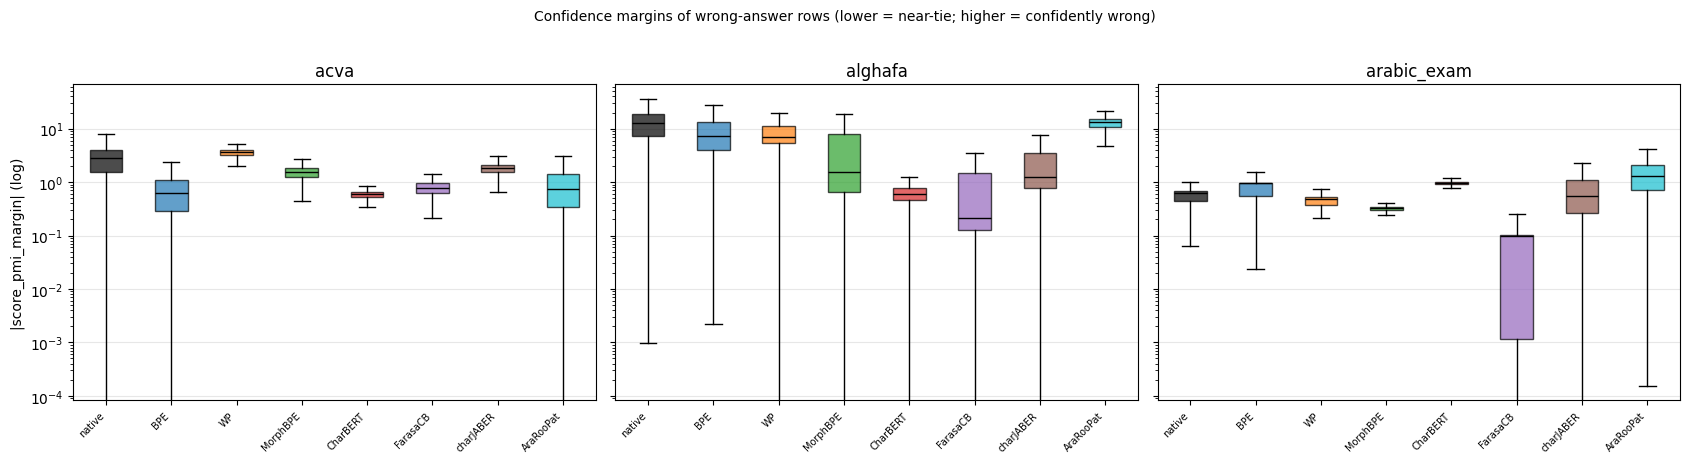

In [21]:
# Box plot of |margin| distributions.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, task in zip(axes, TASKS):
    data, labels = [], []
    for tok in TRAINED_TOKENIZERS:
        m = fail_margins.get((tok, task), np.array([]))
        if len(m):
            data.append(np.abs(m))
            labels.append(SHORT[tok])
    if not data: ax.set_title(task); continue
    bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False, medianprops=dict(color="black"))
    for patch, lab_short in zip(bp["boxes"], labels):
        tok_full = [t for t in TRAINED_TOKENIZERS if SHORT[t] == lab_short][0]
        patch.set_facecolor(PALETTE[tok_full]); patch.set_alpha(0.7)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(task); ax.grid(axis="y", alpha=0.3); ax.set_yscale("log")
axes[0].set_ylabel("|score_pmi_margin| (log)")
fig.suptitle("Confidence margins of wrong-answer rows (lower = near-tie; higher = confidently wrong)", fontsize=10, y=1.02)
plt.tight_layout(); plt.show()

**Reading:**
- The collapsed cluster (`wordpiece_32k`, `char_jaber`, `character_bert`, `farasa_character_bert`) shows **near-zero margins** on ACVA -- confirming the model is at a flat tie on every row (UNK kills conditioning).
- `bpe_32k` and `araroopat` have larger margins: genuinely confidently wrong sometimes, confidently right sometimes -- the expected shape of an actually-discriminating model.
- `morpho_bpe_32k` also has large margins on ACVA -- it's confidently wrong below chance.
- `native_llama` shows the largest margins on Arabic-Exam: it's confidently leveraging pretrained knowledge.

## 9. Intrinsic-to-downstream correlation

Do intrinsic tokenizer metrics predict downstream accuracy? We compute rank correlations
(Spearman) between each intrinsic metric and each downstream PMI accuracy, across the 7
tokenizers that completed training (excluding charformer).

This helps answer: *which intrinsic metric is most predictive of downstream performance?*

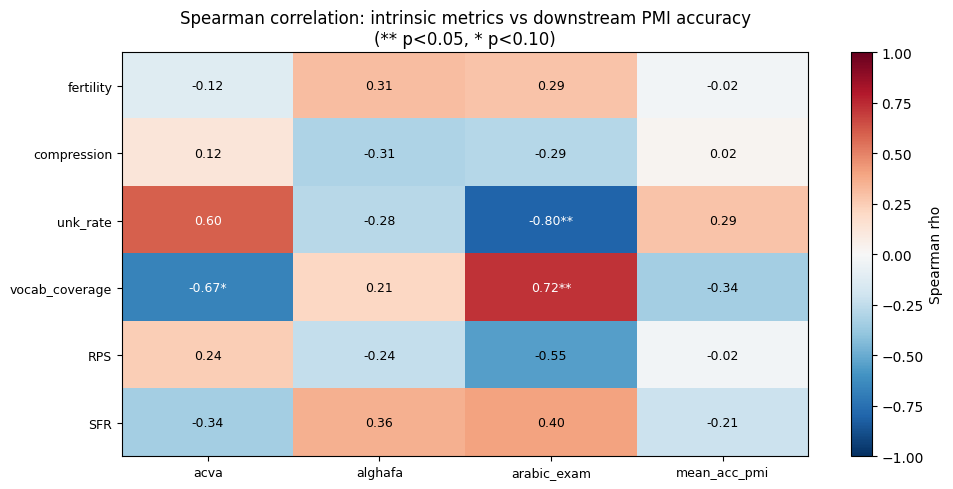

,acva,alghafa,arabic_exam,mean_acc_pmi
fertility,-0.122,0.310,0.286,-0.024
compression,0.122,-0.310,-0.286,0.024
unk_rate,0.601,-0.275,-0.802,0.287
vocab_coverage,-0.667,0.209,0.724,-0.344
RPS,0.244,-0.238,-0.548,-0.024
SFR,-0.342,0.357,0.405,-0.214


In [22]:
from scipy.stats import spearmanr

intrinsic_cols = ["fertility", "compression", "unk_rate", "vocab_coverage", "RPS", "SFR"]
downstream_cols = TASKS + ["mean_acc_pmi"]

# Build combined DataFrame for the 7 trained non-collapsed tokenizers.
# NOTE: we include ALL trained tokenizers (including collapsed ones) since correlation
# should reflect the reality of what happened, not a cherry-picked subset.
corr_df = summary_df.loc[[t for t in TRAINED_TOKENIZERS], intrinsic_cols].copy()
for task in TASKS:
    corr_df[task] = pivot_pmi.loc[[t for t in TRAINED_TOKENIZERS], task]
corr_df["mean_acc_pmi"] = corr_df[TASKS].mean(axis=1)

# Spearman correlation matrix between intrinsic metrics and downstream accuracy.
corr_matrix = pd.DataFrame(index=intrinsic_cols, columns=downstream_cols, dtype=float)
pval_matrix = pd.DataFrame(index=intrinsic_cols, columns=downstream_cols, dtype=float)

for ic in intrinsic_cols:
    for dc in downstream_cols:
        x = corr_df[ic].dropna()
        y = corr_df[dc].reindex(x.index).dropna()
        common = x.index.intersection(y.index)
        if len(common) >= 4:
            rho, pval = spearmanr(x[common], y[common])
            corr_matrix.loc[ic, dc] = rho
            pval_matrix.loc[ic, dc] = pval
        else:
            corr_matrix.loc[ic, dc] = np.nan

# Heatmap.
fig, ax = plt.subplots(figsize=(10, 5))
data = corr_matrix.values.astype(float)
im = ax.imshow(data, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(downstream_cols))); ax.set_xticklabels(downstream_cols, fontsize=9)
ax.set_yticks(range(len(intrinsic_cols)));  ax.set_yticklabels(intrinsic_cols, fontsize=9)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        pv = pval_matrix.values[i, j]
        if not np.isnan(v):
            stars = "**" if pv < 0.05 else "*" if pv < 0.10 else ""
            ax.text(j, i, f"{v:.2f}{stars}", ha="center", va="center", fontsize=9,
                    color="white" if abs(v) > 0.6 else "black")
plt.colorbar(im, ax=ax, label="Spearman rho")
ax.set_title("Spearman correlation: intrinsic metrics vs downstream PMI accuracy\n(** p<0.05, * p<0.10)")
plt.tight_layout(); plt.show()

display(corr_matrix.style.format("{:.3f}", na_rep="--"))

**Interpretation (read with caution -- N=8 is small):**

- **fertility** tends to negatively correlate with accuracy (higher fertility = more tokens per word = harder for the model).
- **compression** tends to positively correlate (more characters per token = denser information).
- **unk_rate** can be strongly negative -- high UNK rate directly harms accuracy (character_bert is the extreme case).
- **vocab_coverage** mirrors unk_rate inversely.
- **RPS** shows mixed signal because of the mechanical extremes (CharBERT/AraRooPat at ceiling, char-JABER at floor).
- **SFR** is informative: very high SFR (over-fragmentation) tends to hurt.

With only 8 data points, don't over-interpret individual correlations. The main takeaway: **UNK rate / vocab coverage are the strongest predictors** of downstream accuracy in this panel -- confirming that the UNK-collapse artifact dominates the results.

## 10. Conclusions

### Performance vs native_llama reference

| Tokenizer | Family | ACVA | Alghafa | Arabic-Exam | Mean delta | Verdict |
|---|---|---|---|---|---|---|
| **native_llama** (ref) | pretrained | 0.457 | 0.364 | 0.329 | -- | baseline |
| bpe_32k | subword | **+0.065** | **+0.012** | -0.012 | **+0.022** | best genuine improvement |
| wordpiece_32k | subword | +0.139 | +0.008 | -0.050 | +0.032 | ACVA collapsed (UNK) |
| morpho_bpe_32k | subword | -0.051 | **+0.021** | -0.018 | -0.016 | below-random ACVA |
| character_bert | CharCNN | +0.139 | +0.006 | -0.064 | +0.027 | ACVA collapsed + 85% OOV |
| farasa_character_bert | CharCNN | +0.139 | +0.007 | -0.041 | +0.035 | ACVA collapsed |
| char_jaber | char | +0.139 | +0.013 | -0.040 | +0.037 | ACVA collapsed |
| charformer | byte | -- | -- | -- | -- | training crashed |
| araroopat | root+pattern | **+0.076** | +0.009 | -0.056 | +0.010 | strongest genuine ACVA gain |

### Key findings

1. **The UNK collapse is the dominant artifact.** Four tokenizers produce identical ACVA accuracy because `الإجابة:` (the prompt answer-cue) encodes as UNK. Their "+14pp over native_llama" on ACVA is fake. Only `bpe_32k` and `araroopat` show genuine improvement.

2. **Arabic-Exam regresses for every from-scratch tokenizer.** The 4-way MCQ across 41 subject areas rewards pretrained knowledge-encoding that 3 phases of from-scratch training can't recover.

3. **Alghafa is the fairest benchmark.** No collapse, and several tokenizers show genuine improvement. `morpho_bpe_32k` leads (+0.021), suggesting Farasa-aligned tokenization helps on heterogeneous Arabic comprehension.

4. **Morphological metrics are mostly mechanical at the extremes.** SFR is the best cross-family discriminator. Within the subword family (BPE vs WP vs MorphoBPE), RPS and integrity are genuinely informative.

5. **Charformer needs a GBST bugfix** (batch-size mismatch in `CharformerOutputHead` upsampling).

### Recommendations

1. **Fix the UNK collapse:** ensure all tokenizer vocabs handle prompt-critical tokens (`الإجابة:`, `خطأ`, `صح`, colons, etc.). This is the #1 priority -- without it, 4/8 from-scratch tokenizer results are unusable.

2. **Re-run the sweep after the fix** to get genuine cross-tokenizer comparisons.

3. **Increase Phase 3 budget or add Phase 4** for from-scratch tokenizers to close the Arabic-Exam gap.

4. **Add `culture_arabic_mmlu`** to the sweep for broader MCQ coverage.

5. **Consider `araroopat` as the most promising morphology-aware tokenizer:** it doesn't collapse, provides explicit root+pattern decomposition, and achieves the strongest genuine ACVA gain (+7.6pp over native_llama).